# Pose experiment suite — real / synthetic / mixed

Repete a avaliação de `classifiers_robot_emotions.ipynb` para três configurações de fonte de pose:

| Experimento | Pose | IMU sintético |
|---|---|---|
| `real_pose` | MotionBERT (vídeo real) | pipeline real |
| `synthetic_pose` | Kimodo (geração a partir de janelas reais) | pipeline Kimodo |
| `mixed_pose` | real + sintético juntos | idem ao modo correspondente |

Cada experimento de pose roda exatamente o mesmo `run_experiment_suite` do notebook original.

In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'pose_module').exists() and (root / 'evaluation').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

try:
    from evaluation.classifiers import (
        EXPERIMENT_SPECS,
        ModelConfig,
        SplitConfig,
        TrainingConfig,
        run_experiment_suite,
    )
    TORCH_READY = True
    TORCH_IMPORT_ERROR = None
except ImportError as exc:
    TORCH_READY = False
    TORCH_IMPORT_ERROR = exc

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT

PosixPath('/home/henriquesouza/IMUGPT')

## Configuração dos experimentos

- `REAL_OUTPUT_ROOT` — diretório do pipeline real (contém `virtual_imu_manifest.jsonl` + `imu.npz` por clipe)
- `SYNTHETIC_MANIFEST` — manifesto gerado por `export-kimodo-virtual-imu`
- `MIXED_MANIFEST` — manifesto gerado por `export-mixed-virtual-imu`

In [2]:
REAL_OUTPUT_ROOT     = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu_v2_all_dataset'
SYNTHETIC_MANIFEST   = PROJECT_ROOT / 'output' / 'exp_synthetic_pose' / 'virtual_imu_manifest.jsonl'
MIXED_MANIFEST       = PROJECT_ROOT / 'output' / 'exp_mixed_pose'      / 'mixed_virtual_imu_manifest.jsonl'
ANCHOR_CATALOG       = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_anchors_hands' / 'kimodo_anchor_catalog.jsonl'

IMU_FEATURE_MODE = 'acc_euler'

DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42,
)

SPLIT_CONFIG = SplitConfig(n_splits=5, random_state=42) if TORCH_READY else None
MODEL_CONFIG = ModelConfig(hidden_dim=128, dropout=0.1, trunk_blocks=2, modality_dropout_p=0.1) if TORCH_READY else None
TRAINING_CONFIG = TrainingConfig(
    batch_size=64, max_epochs=10, learning_rate=2e-3, weight_decay=1e-4,
    device='cuda',
    domain_loss_weight=0.1, flat_tag_loss_weight=0.3, emotion_loss_weight=1.0,
    modality_loss_weight=0.3, stimulus_loss_weight=0.3, use_cb_focal=False,
) if TORCH_READY else None

REQUESTED_ORDER = [
    'vision_only', 'imu_only_r2r', 'imu_only_s2r', 'imu_only_mixed2r',
    'vision_imu_r2r', 'vision_imu_s2r', 'vision_imu_mixed2r',
]

print('REAL_OUTPUT_ROOT:', REAL_OUTPUT_ROOT)
print('SYNTHETIC_MANIFEST:', SYNTHETIC_MANIFEST)
print('MIXED_MANIFEST:', MIXED_MANIFEST)
print('ANCHOR_CATALOG:', ANCHOR_CATALOG)
print('TORCH_READY:', TORCH_READY)

REAL_OUTPUT_ROOT: /home/henriquesouza/IMUGPT/output/robot_emotions_virtual_imu_v2_all_dataset
SYNTHETIC_MANIFEST: /home/henriquesouza/IMUGPT/output/exp_synthetic_pose/virtual_imu_manifest.jsonl
MIXED_MANIFEST: /home/henriquesouza/IMUGPT/output/exp_mixed_pose/mixed_virtual_imu_manifest.jsonl
ANCHOR_CATALOG: /home/henriquesouza/IMUGPT/output/robot_emotions_kimodo_anchors_hands/kimodo_anchor_catalog.jsonl
TORCH_READY: True


## Helpers para carregar manifestos sintéticos

O manifesto sintético não tem `domain`/`user_id`/`tag_number` — esses campos vêm do manifesto real
via `reference_clip_id`. A função abaixo constrói uma capture table compatível com
`build_windowed_multimodal_dataset`.

In [3]:
from pose_module.robot_emotions.metadata import get_protocol_info


def _load_real_manifest_index(real_output_root: Path) -> pd.DataFrame:
    """Carrega o manifesto real e indexa por clip_id para lookup de metadados."""
    path = real_output_root / 'virtual_imu_manifest.jsonl'
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        clip_dir = str(Path(e['artifacts']['virtual_imu_npz_path']).parent.parent.parent.resolve())
        rows.append({
            'clip_id':      str(e['clip_id']),
            'domain':       str(e['domain']),
            'user_id':      int(e['user_id']),
            'tag_number':   int(e['tag_number']),
            'take_id':      e.get('take_id'),
            'clip_dir':     clip_dir,
        })
    return pd.DataFrame(rows).set_index('clip_id')


def _load_anchor_catalog_index(anchor_catalog_path: Path) -> dict[str, tuple[float, float]]:
    """Indexa o anchor catalog por window_id → (start_sec, end_sec)."""
    index = {}
    for line in anchor_catalog_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        wid = e.get('window_id') or e.get('prompt_id')
        if wid and 'window' in e and e['window']:
            index[wid] = (float(e['window']['start_sec']), float(e['window']['end_sec']))
    return index


def _build_synthetic_capture_table(
    manifest_path: Path,
    real_index: pd.DataFrame,
    anchor_index: dict[str, tuple[float, float]],
    *,
    pose_kind_filter: str | None = None,
) -> pd.DataFrame:
    """
    Constrói capture table a partir de um manifesto sintético ou misto.

    emotion/modality/stimulus vêm de get_protocol_info(domain, tag_number) —
    as mesmas classes canônicas usadas pelo experimento real — e não dos
    labels livres do manifesto de geração.
    """
    rows = []
    for line in manifest_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get('status') not in ('ok', 'warning'):
            continue
        pose_kind = e.get('pose_kind', 'synthetic')
        if pose_kind_filter is not None and pose_kind != pose_kind_filter:
            continue

        if pose_kind == 'real':
            artifacts = e.get('artifacts', {})
            pose3d_npz = artifacts.get('pose3d_npz_path')
            virtual_imu_npz = artifacts.get('virtual_imu_npz_path')
            ref_clip_id = str(e['clip_id'])
        else:
            va = e.get('virtual_imu_artifacts', {})
            pose3d_npz = va.get('pose3d_npz_path')
            virtual_imu_npz = va.get('virtual_imu_npz_path')
            ref_clip_id = str(e.get('reference_clip_id') or e.get('clip_id'))

        if pose3d_npz is None or virtual_imu_npz is None:
            continue
        if not Path(pose3d_npz).exists() or not Path(virtual_imu_npz).exists():
            continue
        if ref_clip_id not in real_index.index:
            continue

        real_row = real_index.loc[ref_clip_id]
        protocol = get_protocol_info(real_row['domain'], real_row['tag_number']) or {}
        emotion  = str(protocol.get('emotion', ''))
        modality = str(protocol.get('modality', ''))
        stimulus = str(protocol.get('stimulus', 'None'))

        window_id = e.get('window_id')
        real_imu_time_range_sec = anchor_index.get(window_id) if window_id else None

        sample_id = str(e.get('sample_id') or e.get('prompt_id') or e['clip_id'])
        rows.append({
            'clip_id':                            sample_id,
            'reference_clip_id':                  ref_clip_id,
            'domain':                             real_row['domain'],
            'user_id':                            real_row['user_id'],
            'tag_number':                         real_row['tag_number'],
            'take_id':                            real_row['take_id'],
            'emotion':                            emotion,
            'modality':                           modality,
            'stimulus':                           stimulus,
            'status':                             str(e.get('status', 'ok')),
            'pose3d_npz_path':                    pose3d_npz,
            'virtual_imu_npz_path':               virtual_imu_npz,
            'virtual_imu_frame_aligned_npz_path': None,
            'clip_dir':                           real_row['clip_dir'],
            'pose_kind':                          pose_kind,
            'quality_report':                     {},
            'real_imu_time_range_sec':            real_imu_time_range_sec,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['subject_group'] = df.apply(
        lambda r: f"{r['domain']}_user_{int(r['user_id']):02d}", axis=1
    )
    df['flat_tag'] = df.apply(
        lambda r: f"{r['emotion']}|{r['modality']}|{r['stimulus']}", axis=1
    )
    df['frame_aligned_available'] = False
    n_with_range = df['real_imu_time_range_sec'].notna().sum()
    print(f'  real_imu_time_range_sec preenchido: {n_with_range}/{len(df)} amostras')
    return df.reset_index(drop=True)


def _sort_suite_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    order_map = {name: idx for idx, name in enumerate(REQUESTED_ORDER)}
    df = summary_df.copy()
    df['_sort_key'] = df['experiment_name'].astype(str).map(order_map).fillna(len(REQUESTED_ORDER))
    return df.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)


def _run_pose_experiment(
    label: str,
    captures_df: pd.DataFrame,
) -> dict:
    """Constrói dataset e roda o suite de classificadores para uma capture table."""
    display(Markdown(f'### {label} — dataset'))
    display(captures_df[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
    print({'num_captures': len(captures_df), 'domains': sorted(captures_df['domain'].unique().tolist())})

    dataset_bundle = build_windowed_multimodal_dataset(
        REAL_OUTPUT_ROOT,
        config=DATASET_CONFIG,
        captures_df=captures_df,
    )
    display(dataset_bundle['metadata'].head())
    display(dataset_bundle['alignment_summary'].head())
    print({
        'num_samples':          len(dataset_bundle['metadata']),
        'pose_shape':           dataset_bundle['pose_windows'].shape,
        'imu_real_shape':       dataset_bundle['imu_real_windows'].shape,
        'imu_synthetic_shape':  dataset_bundle['imu_synthetic_windows'].shape,
    })

    if not TORCH_READY:
        display(Markdown(f'**PyTorch não disponível**: `{TORCH_IMPORT_ERROR}`'))
        return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': None}

    display(Markdown(f'### {label} — suite de classificadores'))
    suite_result = run_experiment_suite(
        dataset_bundle,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
    )
    display(_sort_suite_summary(suite_result['summary']))
    display(suite_result['domain_gap_summary'])
    return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': suite_result}


REAL_INDEX = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest index: {len(REAL_INDEX)} clips')
print(f'Anchor catalog index: {len(ANCHOR_INDEX)} janelas')

Real manifest index: 89 clips
Anchor catalog index: 3726 janelas


---
## Experimento 1 — Apenas pose real

Idêntico ao notebook original. Usa `build_classifier_capture_table` com o manifesto real.

In [4]:
CAPTURES_REAL = build_classifier_capture_table(REAL_OUTPUT_ROOT)
RESULT_REAL   = _run_pose_experiment('real_pose', CAPTURES_REAL)

### real_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures': 80, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9


,clip_id,selected_sensors,imu_feature_mode,lag_samples,lag_seconds,correlation_before_dtw,correlation_after_dtw,dtw_normalized_distance,aligned_frequency_hz,num_aligned_frames
0,robot_emotions_10ms_u02_tag01,"[waist, head, left_forearm, right_forearm]",acc_euler,-4,-0.133484,0.026847,0.671229,0.178128,29.966164,2082
1,robot_emotions_10ms_u02_tag05,"[waist, head, left_forearm, right_forearm]",acc_euler,13,0.433823,0.038990,0.567443,0.188057,29.966164,2075
2,robot_emotions_10ms_u02_tag06,"[waist, head, left_forearm, right_forearm]",acc_euler,-15,-0.500565,0.235031,0.712376,0.184795,29.966164,2150
3,robot_emotions_10ms_u02_tag07,"[waist, head, left_forearm, right_forearm]",acc_euler,0,0.000000,0.266520,0.766502,0.161656,29.966164,1938
4,robot_emotions_10ms_u02_tag09,"[waist, head, left_forearm, right_forearm]",acc_euler,9,0.300339,0.116164,0.561349,0.218361,29.966164,2041


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/80 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/80 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/80 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.620246,0.571460,0.600003,0.541095,0.425100,0.364371,0.880966,0.554673,0.425100,0.880966,0.554673,emotion: Anger,4075
1,imu_only_r2r,0.549849,0.507294,0.531771,0.480178,0.379629,0.325396,0.765714,0.504205,0.379629,0.765714,0.504205,emotion: Anger,4075
2,imu_only_s2r,0.446502,0.404463,0.433247,0.384581,0.278347,0.238583,0.680637,0.380520,0.278347,0.680637,0.380520,emotion: Anger,4075
3,imu_only_mixed2r,0.557163,0.512342,0.539169,0.485351,0.377878,0.323895,0.768529,0.525083,0.377878,0.768529,0.525083,emotion: Anger,4075
4,vision_imu_r2r,0.574163,0.532705,0.554719,0.503538,0.408330,0.349997,0.808367,0.505793,0.408330,0.808367,0.505793,emotion: Anger,4075
5,vision_imu_s2r,0.563293,0.506913,0.547208,0.482787,0.337775,0.289522,0.851958,0.500145,0.337775,0.851958,0.500145,emotion: Anger,4075
6,vision_imu_mixed2r,0.600396,0.556586,0.580151,0.526218,0.425155,0.364418,0.858627,0.517406,0.425155,0.858627,0.517406,emotion: Anger,4075


,metric,value
0,imu_only_gap_s2r,0.103347
1,imu_only_gap_mixed2r,-0.007314
2,imu_only_gain_mixed_over_r2r,0.007314
3,imu_only_gain_mixed_over_s2r,0.110662
4,vision_imu_gap_s2r,0.010870
5,vision_imu_gap_mixed2r,-0.026233
6,vision_imu_gain_mixed_over_r2r,0.026233
7,vision_imu_gain_mixed_over_s2r,0.037103


---
## Experimento 2 — Apenas pose sintética (Kimodo)

Cada sample é uma janela de 5 s gerada pelo Kimodo a partir de uma janela do vídeo real.
O IMU real continua vindo do clipe de referência (necessário para alinhamento e rótulos).

In [5]:
CAPTURES_SYNTHETIC = _build_synthetic_capture_table(
    SYNTHETIC_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter='synthetic'
)
RESULT_SYNTHETIC   = _run_pose_experiment('synthetic_pose', CAPTURES_SYNTHETIC)

  real_imu_time_range_sec preenchido: 3726/3726 amostras


### synthetic_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,Neutrality,Standing,None,ok
1,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,Neutrality,Standing,None,ok
2,robot_emotions_10ms_u02_tag01__w002__s000,10ms,2,1,Neutrality,Standing,None,ok
3,robot_emotions_10ms_u02_tag01__w003__s000,10ms,2,1,Neutrality,Standing,None,ok
4,robot_emotions_10ms_u02_tag01__w004__s000,10ms,2,1,Neutrality,Standing,None,ok


{'num_captures': 3726, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01__w000__s000::win...,robot_emotions_10ms_u02_tag01__w000__s000,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.305414,0.840871,0.160227,0.0,0.0,0.0,0.0,5,1,1,9
1,robot_emotions_10ms_u02_tag01__w000__s000::win...,robot_emotions_10ms_u02_tag01__w000__s000,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.305414,0.840871,0.160227,0.0,0.0,0.0,0.0,5,1,1,9
2,robot_emotions_10ms_u02_tag01__w001__s000::win...,robot_emotions_10ms_u02_tag01__w001__s000,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.183466,0.742386,0.199584,0.0,0.0,0.0,0.0,5,1,1,9
3,robot_emotions_10ms_u02_tag01__w001__s000::win...,robot_emotions_10ms_u02_tag01__w001__s000,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.183466,0.742386,0.199584,0.0,0.0,0.0,0.0,5,1,1,9
4,robot_emotions_10ms_u02_tag01__w002__s000::win...,robot_emotions_10ms_u02_tag01__w002__s000,robot_emotions_10ms_u02_tag01__w002__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-7,-0.233333,0.326453,0.812064,0.164817,0.0,0.0,0.0,0.0,5,1,1,9


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/131 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/131 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/131 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.583881,0.544064,0.563662,0.513735,0.424614,0.363955,0.871600,0.455429,0.424614,0.871600,0.455429,emotion: Anger,6529
1,imu_only_r2r,0.526563,0.489061,0.508631,0.462164,0.376555,0.322762,0.767774,0.435359,0.376555,0.767774,0.435359,emotion: Anger,6529
2,imu_only_s2r,0.302971,0.262262,0.296298,0.252253,0.140135,0.120116,0.503470,0.265309,0.140135,0.503470,0.265309,emotion: Anger,6529
3,imu_only_mixed2r,0.541036,0.501933,0.522720,0.474460,0.384625,0.329679,0.794730,0.443752,0.384625,0.794730,0.443752,emotion: Anger,6529
4,vision_imu_r2r,0.585036,0.544005,0.564992,0.513940,0.420912,0.360781,0.883329,0.450867,0.420912,0.883329,0.450867,emotion: Anger,6529
5,vision_imu_s2r,0.509587,0.453634,0.495979,0.433222,0.285776,0.244951,0.878475,0.364512,0.285776,0.878475,0.364512,emotion: Anger,6529
6,vision_imu_mixed2r,0.603887,0.569339,0.581711,0.536075,0.465694,0.399166,0.875756,0.470212,0.465694,0.875756,0.470212,emotion: Anger,6529


,metric,value
0,imu_only_gap_s2r,0.223591
1,imu_only_gap_mixed2r,-0.014473
2,imu_only_gain_mixed_over_r2r,0.014473
3,imu_only_gain_mixed_over_s2r,0.238064
4,vision_imu_gap_s2r,0.075448
5,vision_imu_gap_mixed2r,-0.018851
6,vision_imu_gain_mixed_over_r2r,0.018851
7,vision_imu_gain_mixed_over_s2r,0.094300


---
## Experimento 3 — Pose real + sintética (misto)

Concatena os dois conjuntos acima. Cada entrada mantém o campo `pose_kind` para rastreabilidade.

In [6]:
CAPTURES_MIXED = _build_synthetic_capture_table(
    MIXED_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter=None
)
RESULT_MIXED   = _run_pose_experiment('mixed_pose', CAPTURES_MIXED)

  real_imu_time_range_sec preenchido: 3726/3813 amostras


### mixed_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures': 3813, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,5,1,1,9
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,5,1,1,9
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,5,1,1,9
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,5,1,1,9
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,5,1,1,9


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/218 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/218 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/218 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.615255,0.577277,0.593191,0.544181,0.463345,0.397152,0.896133,0.486288,0.463345,0.896133,0.486288,emotion: Anger,10525
1,imu_only_r2r,0.542556,0.505183,0.523839,0.477107,0.393062,0.336910,0.786184,0.448423,0.393062,0.786184,0.448423,emotion: Anger,10525
2,imu_only_s2r,0.415903,0.369988,0.404843,0.353399,0.232245,0.199067,0.683632,0.331830,0.232245,0.683632,0.331830,emotion: Anger,10525
3,imu_only_mixed2r,0.541476,0.500921,0.523417,0.473831,0.379254,0.325075,0.783837,0.461338,0.379254,0.783837,0.461338,emotion: Anger,10525
4,vision_imu_r2r,0.581399,0.534857,0.562579,0.506627,0.395232,0.338770,0.916135,0.432831,0.395232,0.916135,0.432831,emotion: Anger,10525
5,vision_imu_s2r,0.522208,0.469597,0.507362,0.447328,0.311762,0.267225,0.884688,0.370174,0.311762,0.884688,0.370174,emotion: Anger,10525
6,vision_imu_mixed2r,0.580596,0.537797,0.561100,0.508554,0.409402,0.350916,0.890725,0.441660,0.409402,0.890725,0.441660,emotion: Anger,10525


,metric,value
0,imu_only_gap_s2r,0.126654
1,imu_only_gap_mixed2r,0.001080
2,imu_only_gain_mixed_over_r2r,-0.001080
3,imu_only_gain_mixed_over_s2r,0.125574
4,vision_imu_gap_s2r,0.059191
5,vision_imu_gap_mixed2r,0.000804
6,vision_imu_gain_mixed_over_r2r,-0.000804
7,vision_imu_gain_mixed_over_s2r,0.058388


---
## Comparação dos três experimentos

In [7]:
frames = []
for result in (RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED):
    if result['suite_result'] is None:
        continue
    df = _sort_suite_summary(result['suite_result']['summary']).copy()
    df.insert(0, 'pose_experiment', result['label'])
    frames.append(df)
if frames:
    display(pd.concat(frames, ignore_index=True))

,pose_experiment,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,real_pose,vision_only,0.620246,0.571460,0.600003,0.541095,0.425100,0.364371,0.880966,0.554673,0.425100,0.880966,0.554673,emotion: Anger,4075
1,real_pose,imu_only_r2r,0.549849,0.507294,0.531771,0.480178,0.379629,0.325396,0.765714,0.504205,0.379629,0.765714,0.504205,emotion: Anger,4075
2,real_pose,imu_only_s2r,0.446502,0.404463,0.433247,0.384581,0.278347,0.238583,0.680637,0.380520,0.278347,0.680637,0.380520,emotion: Anger,4075
3,real_pose,imu_only_mixed2r,0.557163,0.512342,0.539169,0.485351,0.377878,0.323895,0.768529,0.525083,0.377878,0.768529,0.525083,emotion: Anger,4075
4,real_pose,vision_imu_r2r,0.574163,0.532705,0.554719,0.503538,0.408330,0.349997,0.808367,0.505793,0.408330,0.808367,0.505793,emotion: Anger,4075
5,real_pose,vision_imu_s2r,0.563293,0.506913,0.547208,0.482787,0.337775,0.289522,0.851958,0.500145,0.337775,0.851958,0.500145,emotion: Anger,4075
6,real_pose,vision_imu_mixed2r,0.600396,0.556586,0.580151,0.526218,0.425155,0.364418,0.858627,0.517406,0.425155,0.858627,0.517406,emotion: Anger,4075
7,synthetic_pose,vision_only,0.583881,0.544064,0.563662,0.513735,0.424614,0.363955,0.871600,0.455429,0.424614,0.871600,0.455429,emotion: Anger,6529
8,synthetic_pose,imu_only_r2r,0.526563,0.489061,0.508631,0.462164,0.376555,0.322762,0.767774,0.435359,0.376555,0.767774,0.435359,emotion: Anger,6529
9,synthetic_pose,imu_only_s2r,0.302971,0.262262,0.296298,0.252253,0.140135,0.120116,0.503470,0.265309,0.140135,0.503470,0.265309,emotion: Anger,6529


## Confusion matrices (melhor fold por experimento)

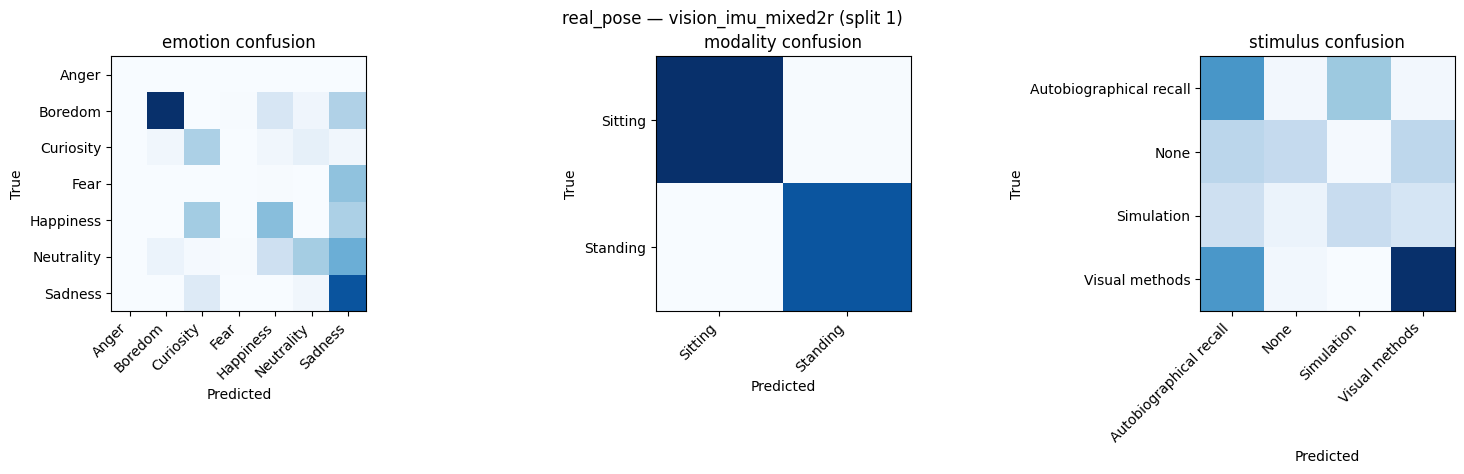

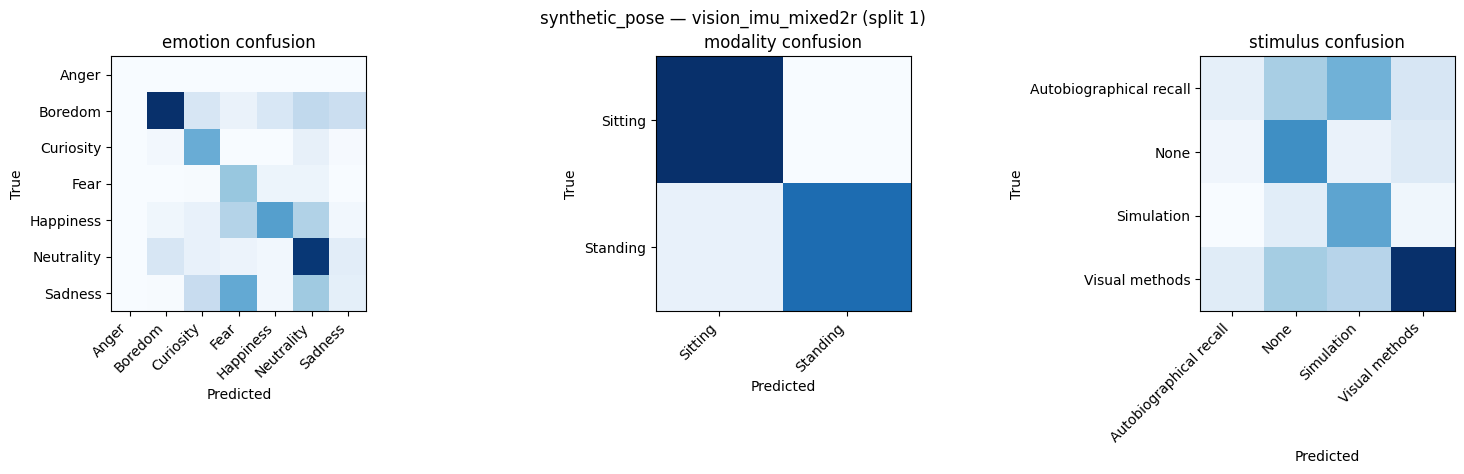

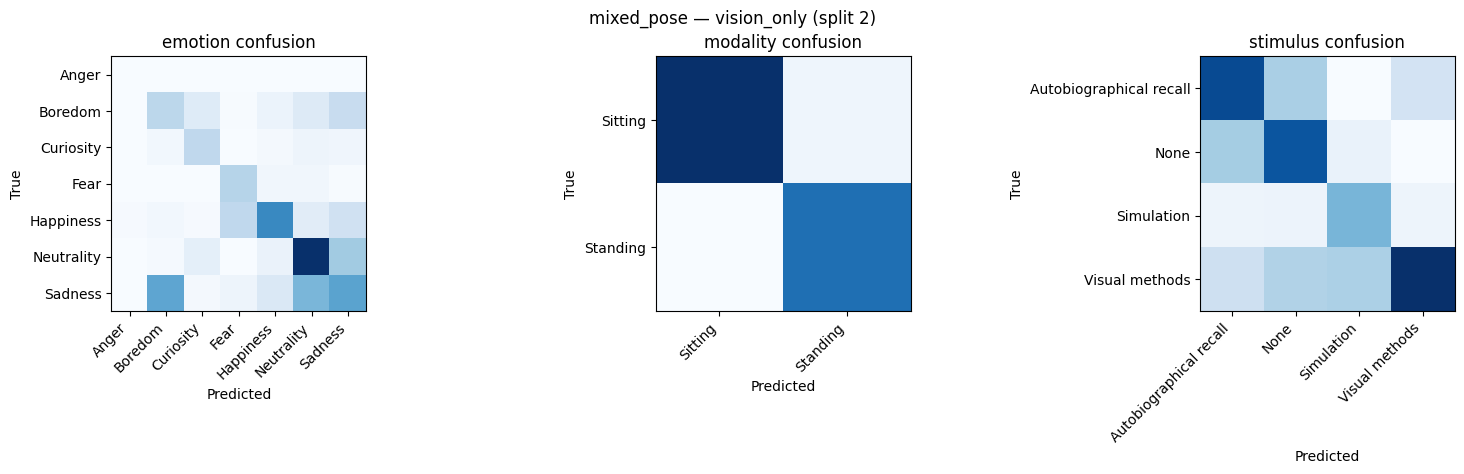

In [8]:
if TORCH_READY:
    from evaluation.classifiers.metrics import plot_confusion_matrices

    for result in (RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED):
        suite = result['suite_result']
        if suite is None:
            continue
        best_experiment_name = suite['summary'].iloc[0]['experiment_name']
        best_result = max(
            (r for r in suite['results'] if r['experiment_name'] == best_experiment_name),
            key=lambda r: float(r['metrics'].get('global_score_macro_f1_mean') or float('-inf')),
        )
        split_suffix = '' if best_result.get('split_id') is None else f" (split {best_result['split_id']})"
        fig, axes = plot_confusion_matrices(best_result['metrics'], result['dataset_bundle']['label_encoders'])
        fig.suptitle(f"{result['label']} — {best_experiment_name}{split_suffix}", y=1.02)
        plt.show()